# NBA Player Points Prediction

Predict next-game scoring from recent performance, playing time, usage, matchup context, rest, and player archetype.

## Environment Setup and Data Loading

Import the libraries used throughout the analysis and load the game-level player statistics.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import pylab as plt
from scipy.stats import zscore, gaussian_kde
from sklearn.datasets import make_swiss_roll

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/PlayerStatistics.csv', on_bad_lines='skip')

## Data Cleaning

Filter the data to the target season, remove unused fields and DNP records, and retain rotation players.

In [ ]:
# Remove data from before 2024-25 season and drop unnecessary columns
df['gameDateTimeEst'] = pd.to_datetime(df['gameDateTimeEst'])
df = df[df['gameDateTimeEst'] >= '2024-10-22']
df = df.drop(columns=['playerteamCity', 'opponentteamCity','fieldGoalsMade',
            'threePointersMade','freeThrowsMade', 'gameLabel',
            'gameSubLabel', 'seriesGameNumber', 'gameType'], errors="ignore")

# Drop DNP rows
df = df[df['numMinutes'] != 0]
df = df[df['numMinutes'].notna()]

# Clear bench players
avg_minutes = df.groupby("personId")["numMinutes"].mean()
rotation_ids = avg_minutes[avg_minutes >= 20].index
df = df[df["personId"].isin(rotation_ids)]

print(f"Rotation players retained: {df['personId'].nunique()}")
print(f"Total game rows after cleaning: {df.shape[0]}")
df.head()



Rotation players retained: 312
Total game rows after cleaning: 37757


,firstName,lastName,personId,gameId,gameDateTimeEst,playerteamName,opponentteamName,win,home,numMinutes,...,threePointersAttempted,threePointersPercentage,freeThrowsAttempted,freeThrowsPercentage,reboundsDefensive,reboundsOffensive,reboundsTotal,foulsPersonal,turnovers,plusMinusPoints
0,Dorian,Finney-Smith,1627827,22501007,2026-03-18 21:30:00,Rockets,Lakers,0.0,1,9.30,...,3.0,0.333,0.0,0.000,1.0,1.0,2.0,0.0,0.0,-13.0
1,Luke,Kennard,1628379,22501007,2026-03-18 21:30:00,Lakers,Rockets,1.0,0,17.43,...,2.0,0.500,0.0,0.000,0.0,1.0,1.0,2.0,3.0,7.0
5,Deandre,Ayton,1629028,22501007,2026-03-18 21:30:00,Lakers,Rockets,1.0,0,33.43,...,0.0,0.000,0.0,0.000,3.0,1.0,4.0,3.0,1.0,1.0
6,Luka,Doncic,1629029,22501007,2026-03-18 21:30:00,Lakers,Rockets,1.0,0,37.41,...,17.0,0.412,14.0,0.643,9.0,0.0,9.0,3.0,5.0,2.0
7,Rui,Hachimura,1629060,22501007,2026-03-18 21:30:00,Lakers,Rockets,1.0,0,20.35,...,2.0,1.000,0.0,0.000,2.0,1.0,3.0,1.0,0.0,8.0


## Univariate Exploratory Data Analysis

Examine the distributions of points, minutes, and shot volume.

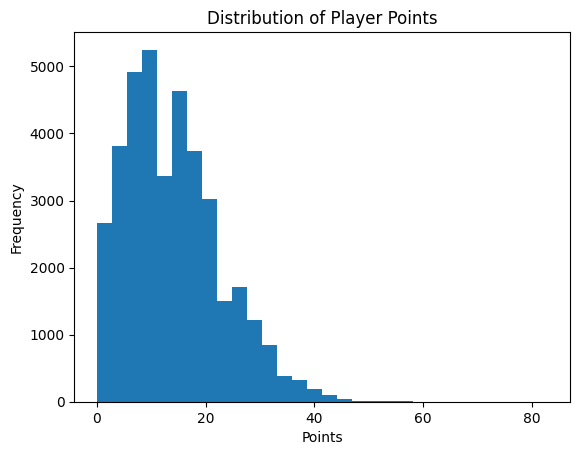

This histogram shows the distribution of player points per game. It is right-skewed, with most of the performances clustered in low scoring ranges with a few high scoring outliers.



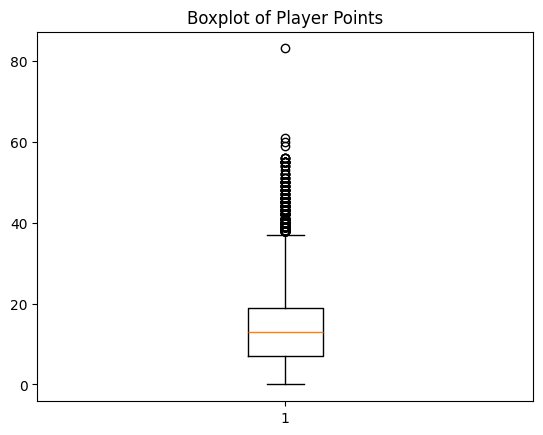

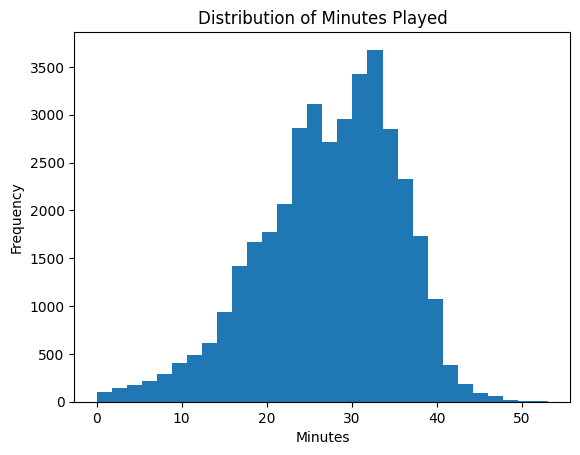

This histogram shows the distribution of minutes played per game. It follows an approximate normal distribution, with the peak being around 28-33 minutes. With the removal of bench players and low-participation games, the dataset is more stable and focused on roatation players.



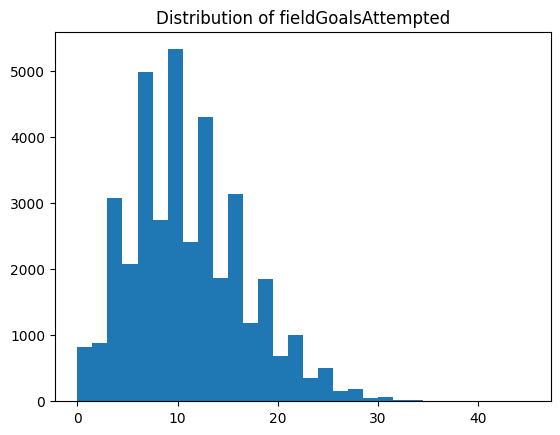

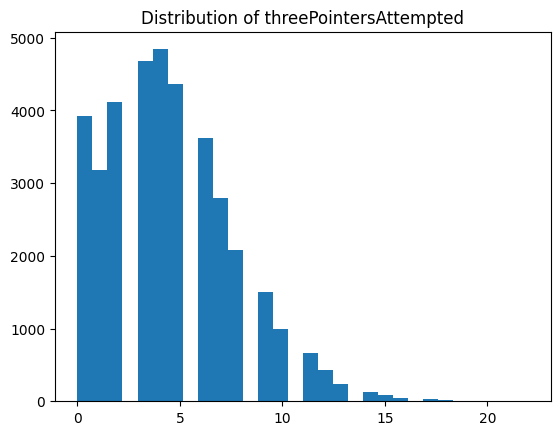

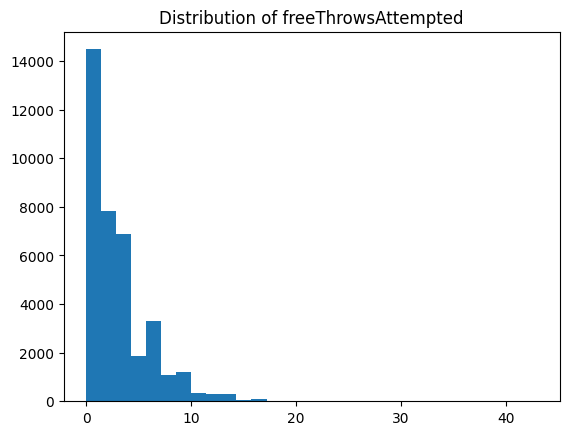

These histgrams repesent the distribution of shot attempts. Each of these are clearly right-skewed, showing variability in offensive usage across games. Shot volume is expected to be a strong predictor for scoring output.



In [ ]:
# Histogram for points to see skew
plt.hist(df["points"], bins=30)
plt.title("Distribution of Player Points")
plt.xlabel("Points")
plt.ylabel("Frequency")
plt.show()
print("This histogram shows the distribution of player points per game. It is right-skewed, with most of the performances clustered in low scoring ranges with a few high scoring outliers.\n")

# Boxplots to find outlier games
plt.boxplot(df["points"])
plt.title("Boxplot of Player Points")
plt.show()
print("")

# Histogram for minutes to understand time spread
plt.hist(df["numMinutes"], bins=30)
plt.title("Distribution of Minutes Played")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()
print("This histogram shows the distribution of minutes played per game. It follows an approximate normal distribution, with the peak being around 28-33 minutes. With the removal of bench players and low-participation games, the dataset is more stable and focused on roatation players.\n")

# Histogram of shot volume to understand volume behavior
cols = ["fieldGoalsAttempted", "threePointersAttempted", "freeThrowsAttempted"]
for c in cols:
    plt.hist(df[c], bins=30)
    plt.title(f"Distribution of {c}")
    plt.show()
print("These histgrams repesent the distribution of shot attempts. Each of these are clearly right-skewed, showing variability in offensive usage across games. Shot volume is expected to be a strong predictor for scoring output.\n")

## Bivariate Exploratory Data Analysis

Explore how points relate to minutes, shot attempts, efficiency, and recent scoring form.

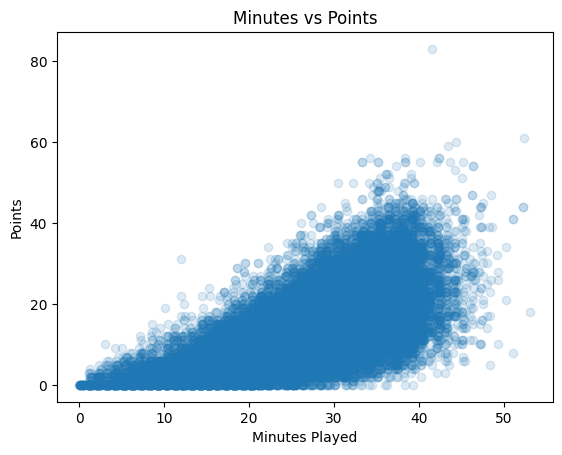

Scatter plot of minutes and points, has a clear positive linear correlation, with some variance. This confirms that playing time is an important factor of scoring output.



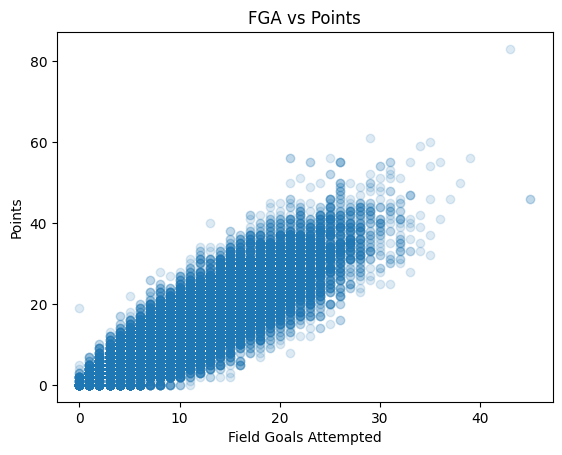

Scatter plot of field goal attempts and points. A clear positive linear correlation is present, with less variance than minutes vs points. This is logical as the more a player shoots, the more that player will score, which is an obvious driver for scoring output.



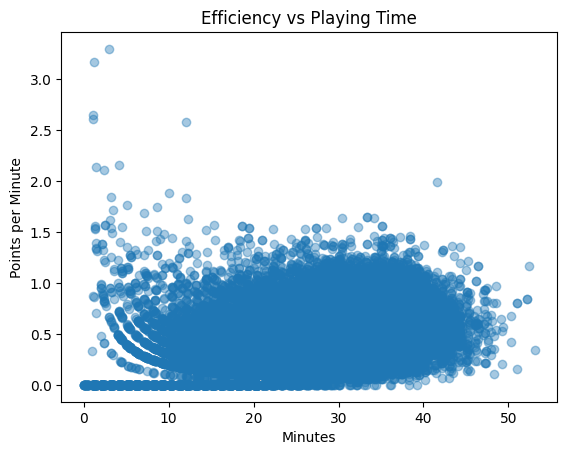

Points per minute vs minutes played starts off with extreme variance, but tightens down and plateaus with still a relatively high variance after around 10 minutes. This shows that once a player reaches rotation-level minutes, scoring efficiency becomes independent from palying time.



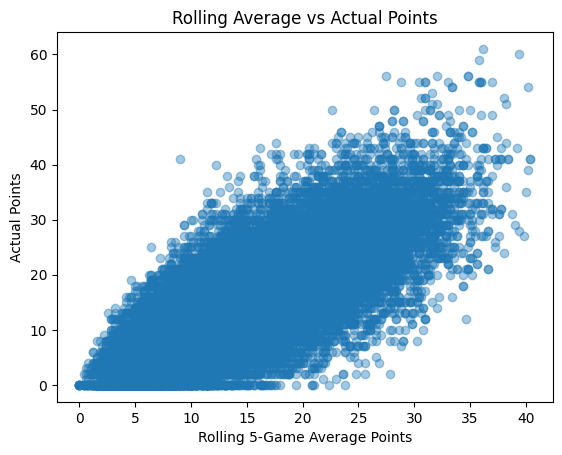

A clear positive linear relationship exists between a player's 5-game rolling average and their actual points, confirming recent scoring history is a strong predictor of current output. The variance widens at higher scoring ranges, reflecting greater unpredictability among high-usage players.

points                     1.000000
pts_per_min                0.866712
fieldGoalsAttempted        0.857208
rolling_pts                0.752968
numMinutes                 0.646579
freeThrowsAttempted        0.632123
threePointersAttempted     0.529856
freeThrowsPercentage       0.452402
fieldGoalsPercentage       0.434134
assists                    0.374570
threePointersPercentage    0.351470
reboundsDefensive          0.342575
turnovers                  0.341419
reboundsTotal              0.322052
plusMinusPoints            0.214700
steals                     0.176450
foulsPersonal              0.149435
reboundsOffensive          0.124843
win                        0.102044
blocks               

In [ ]:
# Minutes vs Points scatter
plt.scatter(df["numMinutes"], df["points"], alpha = 0.15)
plt.xlabel("Minutes Played")
plt.ylabel("Points")
plt.title("Minutes vs Points")
plt.show()
print("Scatter plot of minutes and points, has a clear positive linear correlation, with some variance. This confirms that playing time is an important factor of scoring output.\n")

# Shot Attempts vs Points
plt.scatter(df["fieldGoalsAttempted"], df["points"], alpha = 0.15)
plt.xlabel("Field Goals Attempted")
plt.ylabel("Points")
plt.title("FGA vs Points")
plt.show()
print("Scatter plot of field goal attempts and points. A clear positive linear correlation is present, with less variance than minutes vs points. This is logical as the more a player shoots, the more that player will score, which is an obvious driver for scoring output.\n")

# Points/Min vs Mins
df["pts_per_min"] = df["points"] / df["numMinutes"]
plt.scatter(df["numMinutes"], df["pts_per_min"], alpha=0.4)
plt.xlabel("Minutes")
plt.ylabel("Points per Minute")
plt.title("Efficiency vs Playing Time")
plt.show()
print("Points per minute vs minutes played starts off with extreme variance, but tightens down and plateaus with still a relatively high variance after around 10 minutes. This shows that once a player reaches rotation-level minutes, scoring efficiency becomes independent from palying time.\n")

#Rolling Mean vs Actual Points
df["rolling_pts"] = df.groupby("personId")["points"].transform(lambda x: x.rolling(5).mean())
plt.scatter(df["rolling_pts"], df["points"], alpha=0.4)
plt.xlabel("Rolling 5-Game Average Points")
plt.ylabel("Actual Points")
plt.title("Rolling Average vs Actual Points")
plt.show()
print("A clear positive linear relationship exists between a player's 5-game rolling average and their actual points, confirming recent scoring history is a strong predictor of current output. The variance widens at higher scoring ranges, reflecting greater unpredictability among high-usage players.\n")

# Correlation with points
numeric_cols = df.select_dtypes(include="number")
corr = numeric_cols.corr()["points"].sort_values(ascending=False)
print(corr)



## Opponent Matchup Analysis

Compare a player's average scoring output across opponents.

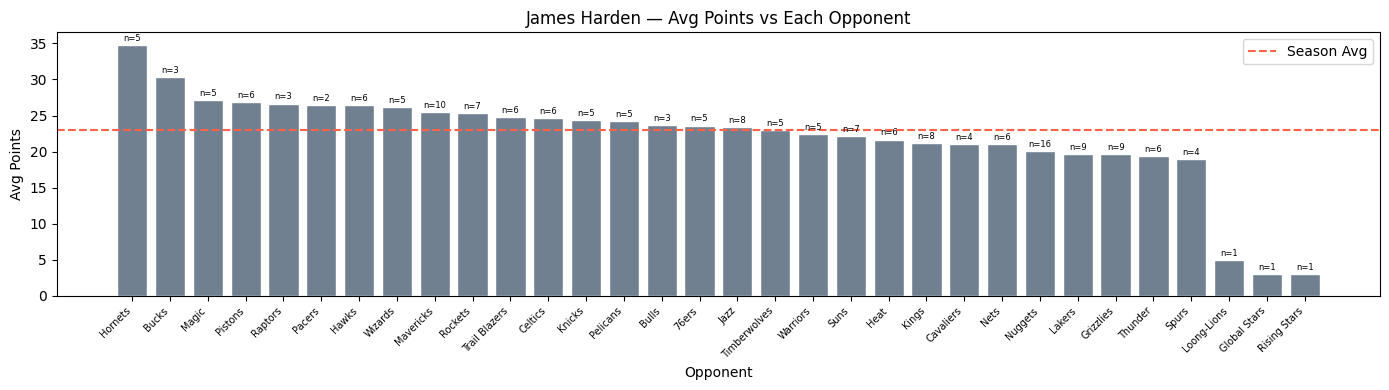

Points breakdown for James Harden against each opponent faced this season. The red dashed line marks their season average. Opponents above the line have allowed above-average scoring, suggesting matchup-dependent variance that opponent encoding in the model may help capture. Note small sample sizes (n=) for opponents faced only once or twice.



In [ ]:
top_id = df.loc[(df["firstName"] == "James") & (df["lastName"] == "Harden"), "personId"].iloc[0]
top_name = df.loc[df["personId"] == top_id, "firstName"].iloc[0] + " " + df.loc[df["personId"] == top_id, "lastName"].iloc[0]

player_opp = (
    df[df["personId"] == top_id]
    .groupby("opponentteamName")["points"]
    .agg(avg_pts="mean", games="count")
    .sort_values("avg_pts", ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(player_opp["opponentteamName"], player_opp["avg_pts"],
              color="slategray", edgecolor="white")

for bar, games in zip(bars, player_opp["games"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"n={games}", ha="center", va="bottom", fontsize=6)

ax.axhline(df[df["personId"] == top_id]["points"].mean(),
           color="tomato", linestyle="--", label="Season Avg")
ax.set_title(f"{top_name} — Avg Points vs Each Opponent")
ax.set_xlabel("Opponent")
ax.set_ylabel("Avg Points")
ax.legend()
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.show()

print(f"Points breakdown for {top_name} against each opponent faced this season. "
      "The red dashed line marks their season average. Opponents above the line have "
      "allowed above-average scoring, suggesting matchup-dependent variance that opponent "
      "encoding in the model may help capture. Note small sample sizes (n=) for opponents "
      "faced only once or twice.\n")

## Home vs. Away Analysis

Evaluate whether game location is associated with a player's scoring output.

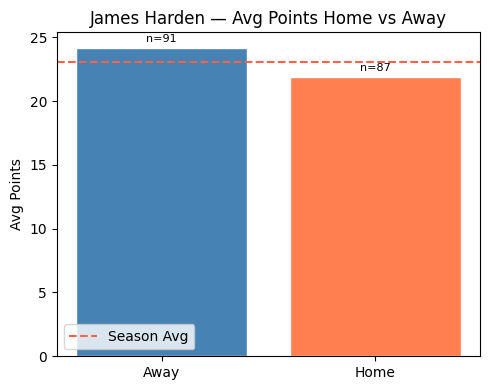

Home vs away scoring breakdown for James Harden. The red dashed line marks their season average. A meaningful gap between home and away would suggest game location is a useful contextual feature for the model.



In [ ]:
top_id = df.loc[(df["firstName"] == "James") & (df["lastName"] == "Harden"), "personId"].iloc[0]
top_name = df.loc[df["personId"] == top_id, "firstName"].iloc[0] + " " + df.loc[df["personId"] == top_id, "lastName"].iloc[0]

player_df = df[df["personId"] == top_id]

home_away = (
    player_df.groupby("home")["points"]
    .agg(avg_pts="mean", games="count")
    .reset_index()
)
home_away["label"] = home_away["home"].map({1: "Home", 0: "Away"})

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(home_away["label"], home_away["avg_pts"],
              color=["steelblue", "coral"], edgecolor="white")

for bar, games in zip(bars, home_away["games"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"n={games}", ha="center", va="bottom", fontsize=8)

ax.axhline(player_df["points"].mean(),
           color="tomato", linestyle="--", label="Season Avg")
ax.set_title(f"{top_name} — Avg Points Home vs Away")
ax.set_ylabel("Avg Points")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Home vs away scoring breakdown for {top_name}. The red dashed line marks their "
      "season average. A meaningful gap between home and away would suggest game location "
      "is a useful contextual feature for the model.\n")

## Time-Based Exploratory Data Analysis

Study rolling performance, usage, recent form, and scoring stability over time.

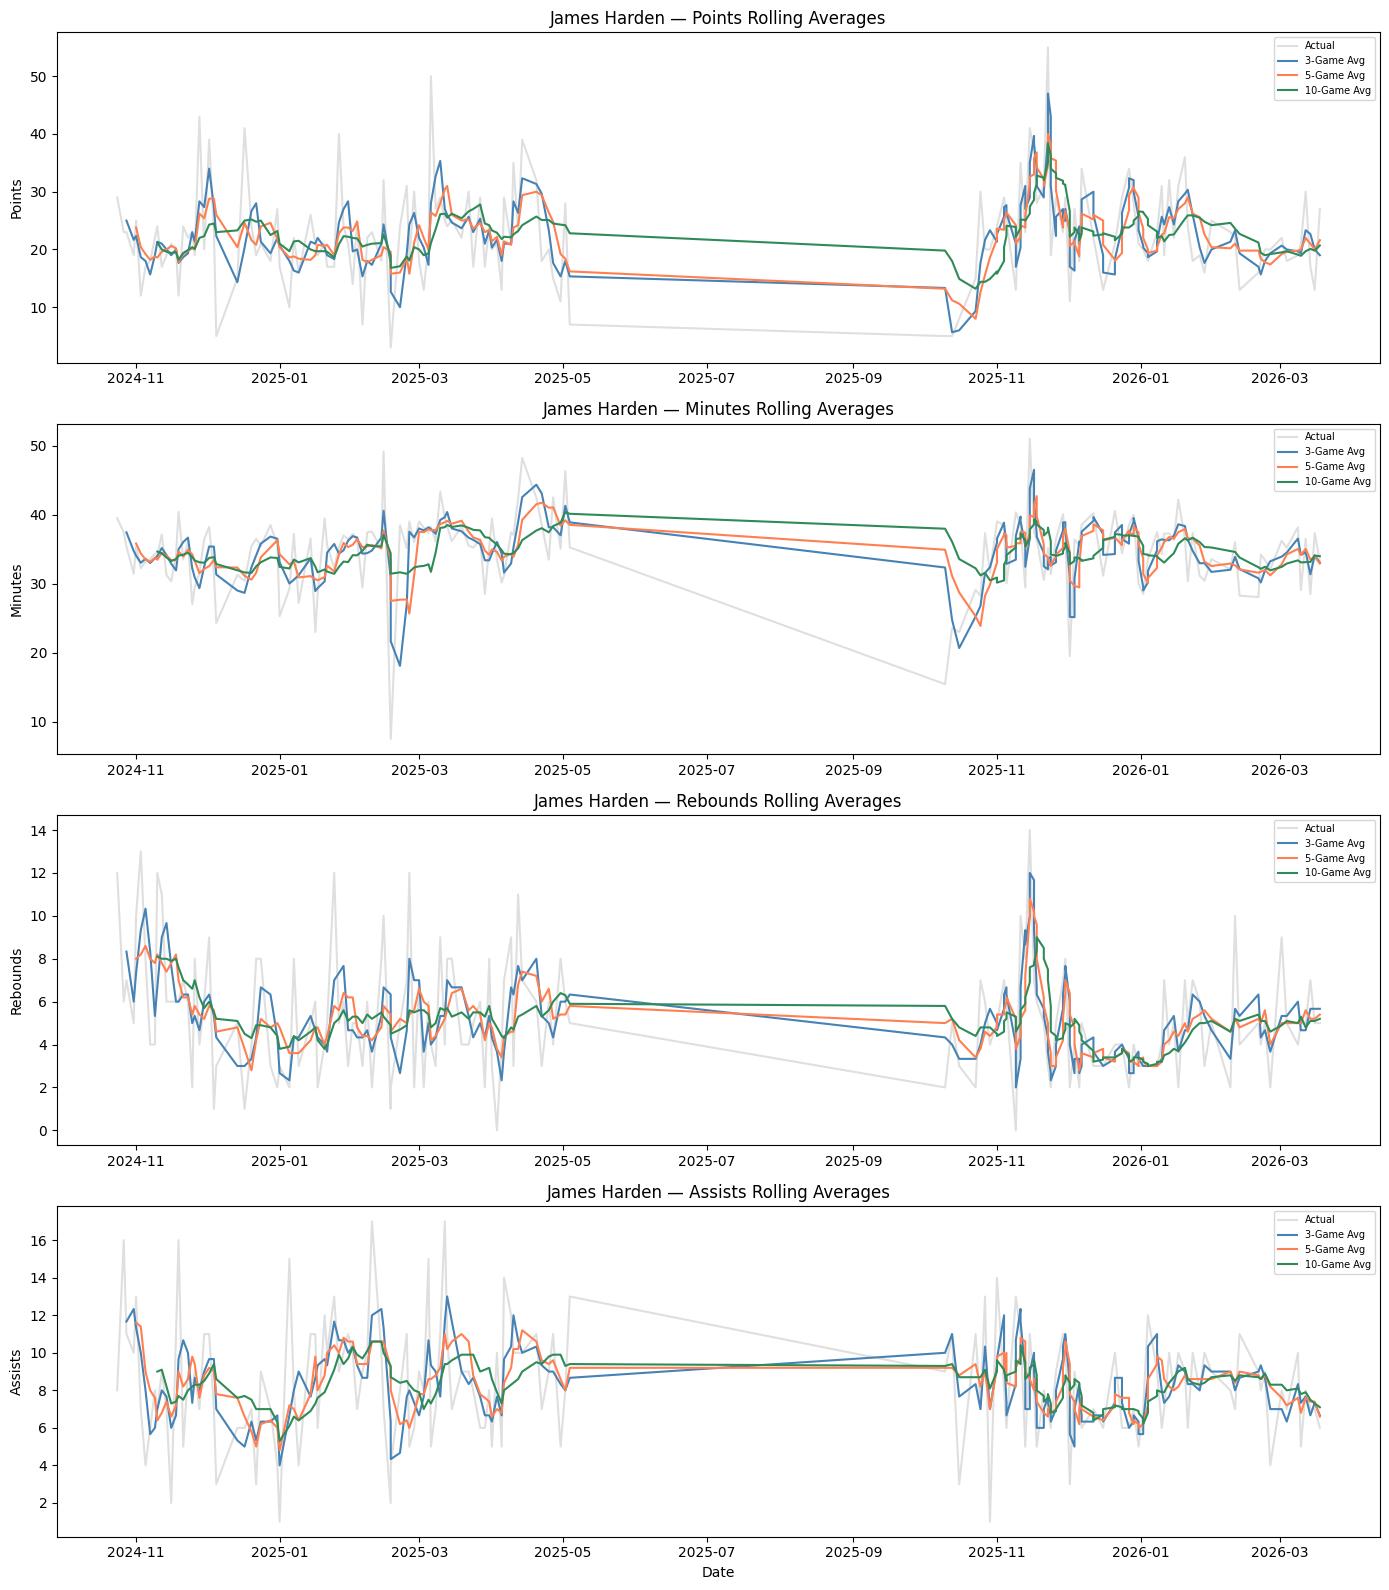

Rolling averages for points, minutes, rebounds, and assists over the season. Shorter windows track hot/cold streaks while longer windows reflect stable trends. Minutes and points tend to move together, reinforcing playing time as a key predictor. Rebounds and assists show role consistency, which helps the model understand player type.



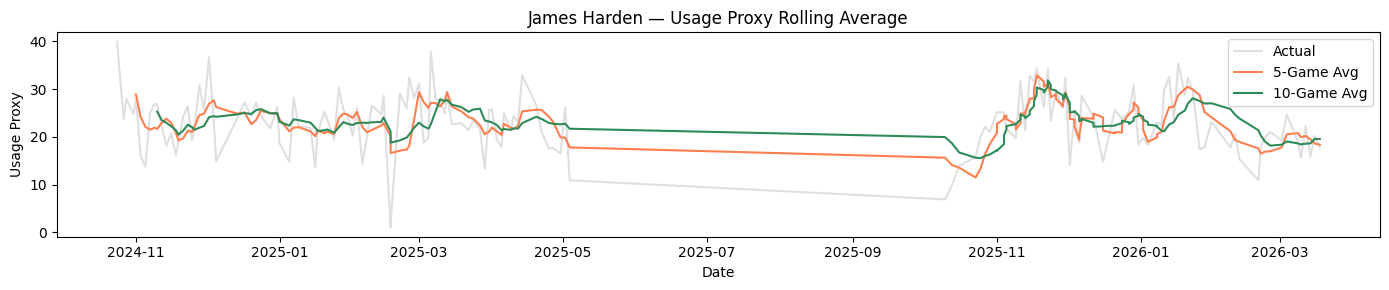

Usage proxy (FGA + 0.44×FTA + turnovers) estimates how many possessions a player consumes per game. Rolling usage is a strong predictor of scoring output since higher usage generally means more scoring opportunities.

MAE — 5-game rolling avg as predictor: 5.48
MAE — season avg as predictor:         5.40
Rolling average underperforms season average, suggesting recent form is not more predictive than overall history.

Std dev — raw points:          8.87
Std dev — 5-game rolling avg:  6.96
Std dev — 10-game rolling avg: 6.56
Variance shrinks as window size increases, confirming that rolling smoothing reduces noise. Wider windows are more stable but less reactive to recent changes.



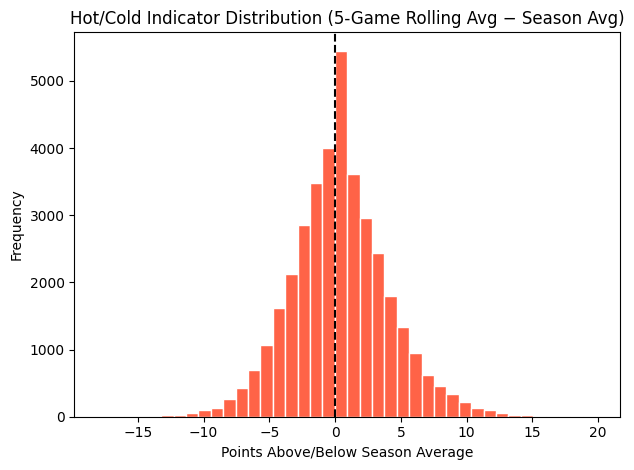

The form delta captures whether a player is currently trending above or below their season baseline. A symmetric distribution centered near zero confirms most players regress to their average over time, while the tails represent genuine hot/cold streaks. This will be engineered as a feature to capture momentum effects in the model.



In [ ]:
df = df.sort_values(["personId", "gameDateTimeEst"]).reset_index(drop=True)

top_id = df.loc[(df["firstName"] == "James") & (df["lastName"] == "Harden"), "personId"].iloc[0]
top_name = df.loc[df["personId"] == top_id, "firstName"].iloc[0] + " " + df.loc[df["personId"] == top_id, "lastName"].iloc[0]
player_df = df[df["personId"] == top_id].copy().reset_index(drop=True)

# Rolling averages for points, minutes, rebounds, assists ---
stats = {
    "points": "Points",
    "numMinutes": "Minutes",
    "reboundsTotal": "Rebounds",
    "assists": "Assists"
}

fig, axes = plt.subplots(len(stats), 1, figsize=(14, 4 * len(stats)))

for ax, (col, label) in zip(axes, stats.items()):
    player_df[f"roll3_{col}"]  = player_df[col].rolling(3).mean()
    player_df[f"roll5_{col}"]  = player_df[col].rolling(5).mean()
    player_df[f"roll10_{col}"] = player_df[col].rolling(10).mean()

    ax.plot(player_df["gameDateTimeEst"], player_df[col],             alpha=0.25, color="gray",      label="Actual")
    ax.plot(player_df["gameDateTimeEst"], player_df[f"roll3_{col}"],  color="steelblue",             label="3-Game Avg")
    ax.plot(player_df["gameDateTimeEst"], player_df[f"roll5_{col}"],  color="coral",                 label="5-Game Avg")
    ax.plot(player_df["gameDateTimeEst"], player_df[f"roll10_{col}"], color="seagreen",              label="10-Game Avg")
    ax.set_title(f"{top_name} — {label} Rolling Averages")
    ax.set_ylabel(label)
    ax.legend(loc="upper right", fontsize=7)

plt.xlabel("Date")
plt.tight_layout()
plt.show()
print("Rolling averages for points, minutes, rebounds, and assists over the season. "
      "Shorter windows track hot/cold streaks while longer windows reflect stable trends. "
      "Minutes and points tend to move together, reinforcing playing time as a key predictor. "
      "Rebounds and assists show role consistency, which helps the model understand player type.\n")

# Usage proxy rolling average (Usage proxy = FGA + 0.44*FTA + turnovers)
player_df["usage_proxy"] = player_df["fieldGoalsAttempted"] + 0.44 * player_df["freeThrowsAttempted"] + player_df["turnovers"]
player_df["roll5_usage"] = player_df["usage_proxy"].rolling(5).mean()
player_df["roll10_usage"] = player_df["usage_proxy"].rolling(10).mean()

plt.figure(figsize=(14, 3))
plt.plot(player_df["gameDateTimeEst"], player_df["usage_proxy"], alpha=0.25, color="gray",     label="Actual")
plt.plot(player_df["gameDateTimeEst"], player_df["roll5_usage"],             color="coral",    label="5-Game Avg")
plt.plot(player_df["gameDateTimeEst"], player_df["roll10_usage"],            color="seagreen", label="10-Game Avg")
plt.title(f"{top_name} — Usage Proxy Rolling Average")
plt.ylabel("Usage Proxy")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()
print("Usage proxy (FGA + 0.44×FTA + turnovers) estimates how many possessions a player "
      "consumes per game. Rolling usage is a strong predictor of scoring output since "
      "higher usage generally means more scoring opportunities.\n")

# Does rolling avg predict better than season avg
df["roll5_pts"]  = df.groupby("personId")["points"].transform(
    lambda x: x.rolling(5, min_periods=1).mean().shift(1))
df["season_avg"] = df.groupby("personId")["points"].transform(
    lambda x: x.expanding().mean().shift(1))

df_eval = df.dropna(subset=["roll5_pts", "season_avg"])
mae_roll   = (df_eval["points"] - df_eval["roll5_pts"]).abs().mean()
mae_season = (df_eval["points"] - df_eval["season_avg"]).abs().mean()

print(f"MAE — 5-game rolling avg as predictor: {mae_roll:.2f}")
print(f"MAE — season avg as predictor:         {mae_season:.2f}")
print(f"Rolling average {'outperforms' if mae_roll < mae_season else 'underperforms'} "
      f"season average, suggesting recent form "
      f"{'is' if mae_roll < mae_season else 'is not'} more predictive than overall history.\n")

# Does variance shrink with rolling smoothing
raw_std   = df["points"].std()
roll3_std = df["roll5_pts"].std()
df["roll10_pts"] = df.groupby("personId")["points"].transform(
    lambda x: x.rolling(10, min_periods=1).mean().shift(1))
roll10_std = df["roll10_pts"].std()

print(f"Std dev — raw points:          {raw_std:.2f}")
print(f"Std dev — 5-game rolling avg:  {roll3_std:.2f}")
print(f"Std dev — 10-game rolling avg: {roll10_std:.2f}")
print("Variance shrinks as window size increases, confirming that rolling smoothing "
      "reduces noise. Wider windows are more stable but less reactive to recent changes.\n")

# Hot/cold indicator distribution
df["form_delta"] = df["roll5_pts"] - df["season_avg"]
plt.hist(df["form_delta"].dropna(), bins=40, color="tomato", edgecolor="white")
plt.axvline(0, color="black", linestyle="--")
plt.title("Hot/Cold Indicator Distribution (5-Game Rolling Avg − Season Avg)")
plt.xlabel("Points Above/Below Season Average")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
print("The form delta captures whether a player is currently trending above or below their "
      "season baseline. A symmetric distribution centered near zero confirms most players "
      "regress to their average over time, while the tails represent genuine hot/cold streaks. "
      "This will be engineered as a feature to capture momentum effects in the model.\n")

## Feature Engineering

Build lagged rolling statistics, efficiency measures, game context, opponent effects, and player archetypes.

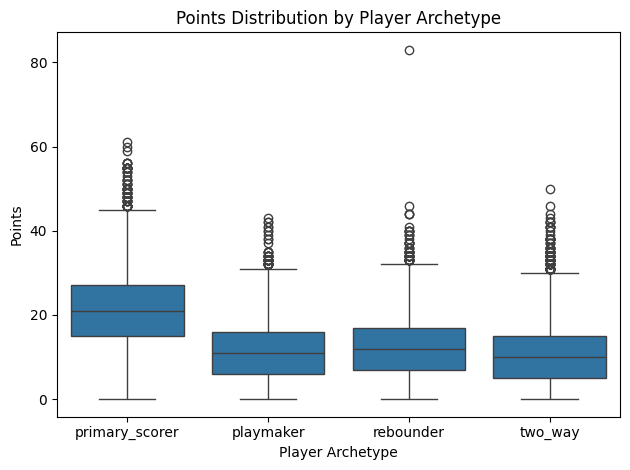

Primary scorers show the highest median points and widest variance, confirming archetype as a meaningful predictor. Two-way and rebounder archetypes cluster at lower scoring ranges with tighter distributions.



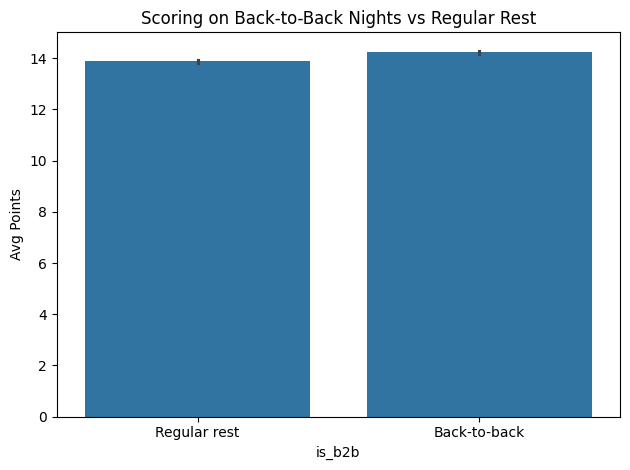

Players score slightly lower on back-to-back nights, validating the is_b2b fatigue feature included in the model.

Feature engineering complete.
Total columns: 175


In [ ]:
df = df.sort_values(["personId", "gameDateTimeEst"]).reset_index(drop=True)

def lag_roll_mean(series, window):
    s = series.fillna(np.nan).astype(float)
    return s.rolling(window, min_periods=1).mean().shift(1)

def lag_roll_std(series, window):
    s = series.fillna(np.nan).astype(float)
    return s.rolling(window, min_periods=2).std().shift(1)

def lag_roll_max(series, window):
    s = series.fillna(np.nan).astype(float)
    return s.rolling(window, min_periods=1).max().shift(1)

def lag_roll_slope(series, window):
    def slope(x):
        x = x[~np.isnan(x)]
        if len(x) < 2:
            return 0
        return np.polyfit(range(len(x)), x, 1)[0]
    s = series.fillna(np.nan).astype(float)
    return s.rolling(window, min_periods=2).apply(slope, raw=True).shift(1)

# Volume-Based Features
df["fga_per_min"] = df["fieldGoalsAttempted"]  / df["numMinutes"].replace(0, pd.NA)
df["pts_per_min"] = df["points"]               / df["numMinutes"].replace(0, pd.NA)
df["reb_per_min"] = df["reboundsTotal"]         / df["numMinutes"].replace(0, pd.NA)
df["ast_per_min"] = df["assists"]              / df["numMinutes"].replace(0, pd.NA)

# Efficiency Metrics
# True Shooting % = points / (2 * (FGA + 0.44 * FTA)) — no made shots needed
df["true_shooting_pct"] = df["points"] / (
    2 * (df["fieldGoalsAttempted"] + 0.44 * df["freeThrowsAttempted"])
).replace(0, pd.NA)

# Effective FG% — derived from existing percentage columns since made shots were dropped
# eFG% = FG% + 0.5 * (3PA / FGA) * 3P%
df["effective_fg_pct"] = (
    df["fieldGoalsPercentage"] +
    0.5 * (df["threePointersAttempted"] / df["fieldGoalsAttempted"].replace(0, pd.NA))
    * df["threePointersPercentage"]
)

# Rolling Features
roll_targets = {
    "points":                  "pts",
    "numMinutes":              "min",
    "reboundsTotal":           "reb",
    "assists":                 "ast",
    "fieldGoalsAttempted":     "fga",
    "freeThrowsAttempted":     "fta",
    "threePointersAttempted":  "3pa",
    "fieldGoalsPercentage":    "fg_pct",
    "threePointersPercentage": "3p_pct",
    "freeThrowsPercentage":    "ft_pct",
    "true_shooting_pct":       "ts",
    "effective_fg_pct":        "efg",
    "pts_per_min":             "pts_per_min",
}

for col, label in roll_targets.items():
    for w in [3, 5, 10]:
        df[f"roll{w}_{label}_mean"]  = df.groupby("personId")[col].transform(
            lambda x: lag_roll_mean(x, w))
    df[f"roll5_{label}_std"]   = df.groupby("personId")[col].transform(
        lambda x: lag_roll_std(x, 5))
    df[f"roll5_{label}_max"]   = df.groupby("personId")[col].transform(
        lambda x: lag_roll_max(x, 5))
    df[f"roll5_{label}_slope"] = df.groupby("personId")[col].transform(
        lambda x: lag_roll_slope(x, 5))

# Usage proxy — no made shots needed
df["usage_proxy"] = df["fieldGoalsAttempted"] + 0.44 * df["freeThrowsAttempted"] + df["turnovers"]
for w in [5, 10]:
    df[f"roll{w}_usage_mean"] = df.groupby("personId")["usage_proxy"].transform(
        lambda x: lag_roll_mean(x, w))

# Season average and form delta
df["season_avg_pts"] = df.groupby("personId")["points"].transform(
    lambda x: x.fillna(np.nan).astype(float).expanding().mean().shift(1))
df["form_delta"] = df["roll5_pts_mean"] - df["season_avg_pts"]

# Contextual Game Features
df["days_rest"] = (
    df.groupby("personId")["gameDateTimeEst"]
    .transform(lambda x: x.diff().dt.days)
    .fillna(3)
)
df["is_b2b"]       = (df["days_rest"] <= 1).astype(int)
df["games_played"] = df.groupby("personId").cumcount()

# Opponent Interaction Features
# Interaction between rolling usage and days rest as a fatigue-volume proxy
df["usage_x_rest"] = df["roll5_usage_mean"] * df["days_rest"]

# Opponent defensive rating — avg points allowed per game by each opponent
# Computed from training period only to avoid data leakage
if "opponentteamName" in df.columns:
    train_games    = df[df["gameDateTimeEst"] <= df["gameDateTimeEst"].quantile(0.8)]
    opp_def_rating = train_games.groupby("opponentteamName")["points"].mean()
    df["opp_avg_pts_allowed"] = df["opponentteamName"].map(opp_def_rating)

# Player Identity Features
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()
df["player_encoded"] = le.fit_transform(df["personId"])

# Player consistency features — how volatile is this player historically
df["player_pts_std"] = df.groupby("personId")["points"].transform(
    lambda x: x.expanding().std().shift(1)
)
df["player_pts_max"] = df.groupby("personId")["points"].transform(
    lambda x: x.expanding().max().shift(1)
)

# Player Archetype Features
from sklearn.cluster import KMeans

archetype_features = ["pts_per_min", "fga_per_min", "ast_per_min", "reb_per_min"]
player_profile = (
    df.groupby("personId")[archetype_features]
    .mean()
    .dropna()
)

scaler_arch    = StandardScaler()
profile_scaled = scaler_arch.fit_transform(player_profile)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
player_profile["archetype"] = kmeans.fit_predict(profile_scaled)

archetype_means = player_profile.groupby("archetype")[archetype_features].mean()
labels = {}
for idx, row in archetype_means.iterrows():
    if row["pts_per_min"] == archetype_means["pts_per_min"].max():
        labels[idx] = "primary_scorer"
    elif row["ast_per_min"] == archetype_means["ast_per_min"].max():
        labels[idx] = "playmaker"
    elif row["reb_per_min"] == archetype_means["reb_per_min"].max():
        labels[idx] = "rebounder"
    else:
        labels[idx] = "two_way"

player_profile["archetype_label"] = player_profile["archetype"].map(labels)
df = df.merge(player_profile[["archetype_label"]], on="personId", how="left")

# Plot Scoring distributions by archetype
sns.boxplot(data=df, x="archetype_label", y="points",
            order=["primary_scorer", "playmaker", "rebounder", "two_way"])
plt.title("Points Distribution by Player Archetype")
plt.xlabel("Player Archetype")
plt.ylabel("Points")
plt.tight_layout()
plt.show()
print("Primary scorers show the highest median points and widest variance, "
      "confirming archetype as a meaningful predictor. Two-way and rebounder "
      "archetypes cluster at lower scoring ranges with tighter distributions.\n")

sns.barplot(data=df, x="is_b2b", y="points", errorbar="se")
plt.xticks([0, 1], ["Regular rest", "Back-to-back"])
plt.title("Scoring on Back-to-Back Nights vs Regular Rest")
plt.ylabel("Avg Points")
plt.tight_layout()
plt.show()
print("Players score slightly lower on back-to-back nights, validating "
      "the is_b2b fatigue feature included in the model.\n")

# KEEP archetypes as a label not feature
df["archetype_label_saved"] = df["archetype_label"]
if "archetype_label" in df.columns:
    df = pd.get_dummies(df, columns=["archetype_label"], prefix="arch", drop_first=True)

# One-hot encode opponent
if "opponentteamName" in df.columns:
    df = pd.get_dummies(df, columns=["opponentteamName"], prefix="opp", drop_first=True)

print("Feature engineering complete.")
print(f"Total columns: {df.shape[1]}")

## Feature Selection

Reduce redundant predictors using correlation filtering and variance inflation factors.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

feature_cols = [c for c in df.columns if any(c.startswith(p) for p in [
    "roll", "opp_", "arch_", "form_delta", "season_avg_pts",
    "days_rest", "is_b2b", "games_played", "home",
    "opp_avg_pts_allowed", "player_encoded",
    "player_pts_std", "player_pts_max"
])]

target_col = "points"
model_df = df[feature_cols + [target_col, "gameDateTimeEst", "personId"]].dropna()

X = model_df[feature_cols]
y = model_df[target_col]

# Correlation filter — drop features correlated > 0.95 with another
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"High-correlation features dropped ({len(high_corr_cols)}):\n{high_corr_cols}\n")

X_filtered = X.drop(columns=high_corr_cols)

# VIF analysis
vif_sample = X_filtered.sample(min(1000, len(X_filtered)), random_state=42)
vif_sample = vif_sample.astype(float)
vif_sample = vif_sample.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

vif_scores = pd.Series(
    [variance_inflation_factor(vif_sample.values, i) for i in range(vif_sample.shape[1])],
    index=vif_sample.columns
).sort_values(ascending=False)

print("Top 20 VIF scores (>10 indicates multicollinearity):")
print(vif_scores.head(20).round(2))

protect = ["roll3_pts_mean", "player_encoded", "player_pts_std", "player_pts_max"]
high_vif_cols = [c for c in vif_scores[vif_scores > 10].index.tolist()
                 if c not in protect]
print(f"\nFeatures with VIF > 10 ({len(high_vif_cols)}):\n{high_vif_cols}")
X_final = X_filtered.drop(columns=high_vif_cols, errors="ignore")
feature_cols_final = X_final.columns.tolist()
print(f"\nFinal feature count after selection: {len(feature_cols_final)}")

High-correlation features dropped (13):
['roll5_pts_mean', 'roll10_pts_mean', 'roll5_fga_mean', 'roll10_fga_mean', 'roll5_3pa_mean', 'roll10_3pa_mean', 'roll3_efg_mean', 'roll5_efg_mean', 'roll10_efg_mean', 'roll5_efg_max', 'roll5_efg_slope', 'roll5_usage_mean', 'roll10_usage_mean']

Top 20 VIF scores (>10 indicates multicollinearity):
roll5_pts            inf
form_delta           inf
opp_Loong-Lions      inf
opp_Magic            inf
opp_Mavericks        inf
opp_Nets             inf
opp_Nuggets          inf
opp_Pacers           inf
opp_Pelicans         inf
opp_Pistons          inf
opp_Raptors          inf
opp_Rockets          inf
opp_Spurs            inf
opp_Suns             inf
opp_Thunder          inf
opp_Timberwolves     inf
opp_Trail Blazers    inf
opp_Wizards          inf
opp_Warriors         inf
opp_76ers            inf
dtype: float64

Features with VIF > 10 (87):
['roll5_pts', 'form_delta', 'opp_Loong-Lions', 'opp_Magic', 'opp_Mavericks', 'opp_Nets', 'opp_Nuggets', 'opp_Pacers',

## Scaling and Time-Based Train/Test Split

Create a chronological split and standardize features for models that are sensitive to scale.

In [ ]:
from sklearn.preprocessing import StandardScaler

model_df = df[feature_cols_final + [target_col, "gameDateTimeEst", "personId", "roll5_pts_mean", "archetype_label_saved"]].dropna()

# Time-based split (no shuffling)
split_date = model_df["gameDateTimeEst"].quantile(0.8)
print(f"Train/test cutoff: {split_date.date()}")

train = model_df[model_df["gameDateTimeEst"] <= split_date]
test  = model_df[model_df["gameDateTimeEst"] >  split_date]

X_train, y_train = train[feature_cols_final], train[target_col]
X_test,  y_test  = test[feature_cols_final],  test[target_col]

print(f"Train: {len(train)} rows  ({train['gameDateTimeEst'].min().date()} → {train['gameDateTimeEst'].max().date()})")
print(f"Test:  {len(test)} rows   ({test['gameDateTimeEst'].min().date()}  → {test['gameDateTimeEst'].max().date()})")

# Log transform skewed features
skewness = X_train.skew().sort_values(ascending=False)
skewed_cols = skewness[skewness.abs() > 1].index.tolist()
skewed_cols = [c for c in skewed_cols if X_train[c].min() >= 0]

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
for col in skewed_cols:
    X_train_scaled[col] = np.log1p(X_train_scaled[col])
    X_test_scaled[col]  = np.log1p(X_test_scaled[col])
print(f"\nLog-transformed {len(skewed_cols)} skewed features.")

# StandardScaler for Linear Regression
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_scaled), columns=feature_cols_final)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_scaled), columns=feature_cols_final)

# X_train / X_test used as-is for Random Forest (no scaling needed)
print("Scaling complete.")
print("  X_train_scaled → Linear Regression")
print("  X_train        → Random Forest")

Train/test cutoff: 2025-12-28
Train: 28824 rows  (2024-10-26 → 2025-12-28)
Test:  7181 rows   (2025-12-29  → 2026-03-12)

Log-transformed 13 skewed features.
Scaling complete.
  X_train_scaled → Linear Regression
  X_train        → Random Forest


## Baseline and Linear Regression

Establish a recent-form baseline and train an interpretable linear regression model.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# ── Baseline: predict each player's rolling average ──────────────────────────
# Something to beat — if your model can't beat this, it's not useful
baseline_train_pred = train["roll5_pts_mean"]
baseline_test_pred  = test["roll5_pts_mean"]
baseline_results = {
    "Train RMSE": np.sqrt(mean_squared_error(y_train, baseline_train_pred.values)),
    "Train MAE":  mean_absolute_error(y_train,         baseline_train_pred.values),
    "Train R²":   r2_score(y_train,                    baseline_train_pred.values),
    "Test RMSE":  np.sqrt(mean_squared_error(y_test,   baseline_test_pred.values)),
    "Test MAE":   mean_absolute_error(y_test,           baseline_test_pred.values),
    "Test R²":    r2_score(y_test,                      baseline_test_pred.values),
}

print("Baseline:")
for k, v in baseline_results.items():
    print(f"  {k}: {v:.3f}" if v != "-" else f"  {k}: {v}")

# ── Linear Regression (uses scaled data) ─────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_train_pred = lr.predict(X_train_scaled)
lr_test_pred  = lr.predict(X_test_scaled)

lr_results = {
    "Train RMSE": np.sqrt(mean_squared_error(y_train, lr_train_pred)),
    "Train MAE":  mean_absolute_error(y_train,         lr_train_pred),
    "Train R²":   r2_score(y_train,                    lr_train_pred),
    "Test RMSE":  np.sqrt(mean_squared_error(y_test,   lr_test_pred)),
    "Test MAE":   mean_absolute_error(y_test,           lr_test_pred),
    "Test R²":    r2_score(y_test,                      lr_test_pred),
}
print("\nLinear Regression:")
for k, v in lr_results.items():
    print(f"  {k}: {v:.3f}")

Baseline:
  Train RMSE: 7.061
  Train MAE: 5.455
  Train R²: 0.374
  Test RMSE: 7.090
  Test MAE: 5.522
  Test R²: 0.309

Linear Regression:
  Train RMSE: 5.743
  Train MAE: 4.471
  Train R²: 0.586
  Test RMSE: 5.813
  Test MAE: 4.520
  Test R²: 0.536


## Random Forest

Train and evaluate a nonlinear tree ensemble.

In [ ]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10,
                           min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_test_pred  = rf.predict(X_test)

rf_results = {
    "Train RMSE": np.sqrt(mean_squared_error(y_train, rf_train_pred)),
    "Train MAE":  mean_absolute_error(y_train,         rf_train_pred),
    "Train R²":   r2_score(y_train,                    rf_train_pred),
    "Test RMSE":  np.sqrt(mean_squared_error(y_test,   rf_test_pred)),
    "Test MAE":   mean_absolute_error(y_test,           rf_test_pred),
    "Test R²":    r2_score(y_test,                      rf_test_pred),
}
print("\nRandom Forest:")
for k, v in rf_results.items():
    print(f"  {k}: {v:.3f}")


Random Forest:
  Train RMSE: 5.065
  Train MAE: 3.957
  Train R²: 0.678
  Test RMSE: 5.805
  Test MAE: 4.514
  Test R²: 0.537


## XGBoost

Tune and evaluate a gradient-boosted tree model.

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

X_train = X_train.astype(float)
X_test  = X_test.astype(float)

# Reset indices so predictions align correctly
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)
test    = test.reset_index(drop=True)

param_grid = {
    "max_depth":        [3, 4, 5, 6],
    "learning_rate":    [0.01, 0.03, 0.05, 0.1],
    "min_child_weight": [3, 5, 7, 10],
    "subsample":        [0.7, 0.8, 0.9],
}

grid = GridSearchCV(
    XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    param_grid, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1
)
grid.fit(X_train, y_train)
print(f"Best params: {grid.best_params_}")
print(f"Best CV RMSE: {-grid.best_score_:.3f}")

# ── XGBoost ───────────────────────────────────────────────────────────────────
xgb = XGBRegressor(
    **grid.best_params_,
    n_estimators=500,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_train_pred = xgb.predict(X_train)
xgb_test_pred  = xgb.predict(X_test)

xgb_results = {
    "Train RMSE": np.sqrt(mean_squared_error(y_train, xgb_train_pred)),
    "Train MAE":  mean_absolute_error(y_train,         xgb_train_pred),
    "Train R²":   r2_score(y_train,                    xgb_train_pred),
    "Test RMSE":  np.sqrt(mean_squared_error(y_test,   xgb_test_pred)),
    "Test MAE":   mean_absolute_error(y_test,           xgb_test_pred),
    "Test R²":    r2_score(y_test,                      xgb_test_pred),
}

print("\nXGBoost (tuned):")
for k, v in xgb_results.items():
    print(f"  {k}: {v:.3f}")

Best params: {'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 3, 'subsample': 0.9}
Best CV RMSE: 5.684

XGBoost (tuned):
  Train RMSE: 4.946
  Train MAE: 3.864
  Train R²: 0.693
  Test RMSE: 6.017
  Test MAE: 4.663
  Test R²: 0.503


## Model Comparison

Compare train and test RMSE, MAE, and R² across all approaches.

In [ ]:
results_df = pd.DataFrame({
    "Baseline":      list(baseline_results.values()),
    "Linear Reg":    list(lr_results.values()),
    "Random Forest": list(rf_results.values()),
    "XGBoost":       list(xgb_results.values()),
}, index=["Train RMSE", "Train MAE", "Train R²", "Test RMSE", "Test MAE", "Test R²"])

print("\n", results_df.round(3))


             Baseline  Linear Reg  Random Forest  XGBoost
Train RMSE     7.061       5.743          5.065    4.946
Train MAE      5.455       4.471          3.957    3.864
Train R²       0.374       0.586          0.678    0.693
Test RMSE      7.090       5.813          5.805    6.017
Test MAE       5.522       4.520          4.514    4.663
Test R²        0.309       0.536          0.537    0.503


## Performance by Player Archetype

Measure model errors separately for primary scorers, playmakers, rebounders, and two-way players.

In [28]:
test_arch = test.copy()
test_arch["archetype_label"] = test["archetype_label_saved"]
test_arch["baseline_pred"] = test_arch["roll5_pts_mean"]
test_arch["lr_pred"]       = lr.predict(X_test_scaled)
test_arch["rf_pred"]       = rf.predict(X_test)
test_arch["xgb_pred"]      = xgb.predict(X_test)

archetypes = ["primary_scorer", "playmaker", "rebounder", "two_way"]
rows = []

for arch in archetypes:
    mask = test_arch["archetype_label"] == arch
    subset = test_arch[mask]
    actual = subset["points"]

    rows.append({
        "Archetype":          arch,
        "N Games":            len(subset),
        "Baseline RMSE":      np.sqrt(mean_squared_error(actual, subset["baseline_pred"])),
        "Baseline MAE":       mean_absolute_error(actual, subset["baseline_pred"]),
        "Baseline R²":        r2_score(actual, subset["baseline_pred"]),
        "Lin Reg RMSE":       np.sqrt(mean_squared_error(actual, subset["lr_pred"])),
        "Lin Reg MAE":        mean_absolute_error(actual, subset["lr_pred"]),
        "Lin Reg R²":         r2_score(actual, subset["lr_pred"]),
        "Rand Forest RMSE":   np.sqrt(mean_squared_error(actual, subset["rf_pred"])),
        "Rand Forest MAE":    mean_absolute_error(actual, subset["rf_pred"]),
        "Rand Forest R²":     r2_score(actual, subset["rf_pred"]),
        "XGBoost RMSE":       np.sqrt(mean_squared_error(actual, subset["xgb_pred"])),
        "XGBoost MAE":        mean_absolute_error(actual, subset["xgb_pred"]),
        "XGBoost R²":         r2_score(actual, subset["xgb_pred"]),
    })

arch_df = pd.DataFrame(rows).set_index("Archetype")
print(arch_df.round(3))

                N Games  Baseline RMSE  Baseline MAE  Baseline R²  \
Archetype                                                           
primary_scorer     1986          8.385         6.548        0.172   
playmaker          1014          6.580         5.127        0.156   
rebounder          1280          6.324         4.947        0.097   
two_way            2901          6.596         5.211        0.116   

                Lin Reg RMSE  Lin Reg MAE  Lin Reg R²  Rand Forest RMSE  \
Archetype                                                                 
primary_scorer         6.865        5.370       0.445             6.835   
playmaker              5.472        4.226       0.416             5.486   
rebounder              5.211        4.102       0.387             5.208   
two_way                5.378        4.225       0.413             5.381   

                Rand Forest MAE  Rand Forest R²  XGBoost RMSE  XGBoost MAE  \
Archetype                                               

## Per-Player Model Performance

Identify the players whose scoring is predicted most consistently by each model.

In [31]:
player_results = []

for pid in test["personId"].unique():
    subset = test[test["personId"] == pid].drop_duplicates(subset="gameDateTimeEst", keep="first")
    if len(subset) < 10:
        continue

    actual = subset[target_col].values
    subset_X = subset[feature_cols_final].astype(float)
    subset_scaled = pd.DataFrame(
        scaler.transform(subset_X), columns=feature_cols_final
    )

    player_results.append({
        "Name":      df.loc[df["personId"] == pid, "firstName"].iloc[0] + " " +
                     df.loc[df["personId"] == pid, "lastName"].iloc[0],
        "Archetype": df.loc[df["personId"] == pid, "archetype_label_saved"].iloc[0],
        "N Games":   len(subset),
        "LR R²":     round(r2_score(actual, lr.predict(subset_scaled)), 3),
        "RF R²":     round(r2_score(actual, rf.predict(subset_X)), 3),
        "XGB R²":    round(r2_score(actual, xgb.predict(subset_X)), 3),
    })

player_r2_df = pd.DataFrame(player_results)

print("── Top 20 by Linear Regression R² ──")
print(player_r2_df.sort_values("LR R²", ascending=False).head(20).to_string(index=False))

print("\n── Top 20 by Random Forest R² ──")
print(player_r2_df.sort_values("RF R²", ascending=False).head(20).to_string(index=False))

print("\n── Top 20 by XGBoost R² ──")
print(player_r2_df.sort_values("XGB R²", ascending=False).head(20).to_string(index=False))

── Top 20 by Linear Regression R² ──
                Name      Archetype  N Games  LR R²  RF R²  XGB R²
        Jusuf Nurkic      rebounder       12  0.495  0.403   0.475
        Devin Booker primary_scorer       24  0.471  0.317  -0.058
        Ryan Rollins      playmaker       30  0.420  0.436   0.418
        Nikola Jovic        two_way       22  0.419  0.453   0.477
          Coby White primary_scorer       19  0.419  0.333   0.320
          Sam Hauser        two_way       31  0.401  0.421   0.326
      Scottie Barnes primary_scorer       32  0.397  0.429   0.077
          Tari Eason      rebounder       27  0.381  0.326   0.318
Collin Murray-Boyles        two_way       18  0.369  0.187   0.213
   Russell Westbrook      playmaker       27  0.361  0.287   0.186
          Ace Bailey        two_way       28  0.360  0.288   0.334
          RJ Barrett primary_scorer       22  0.359  0.303   0.216
         Moses Moody        two_way       25  0.353  0.275   0.237
        James Harden prim

## Individual Player Predictions

Compare actual and predicted points across games for a selected player.

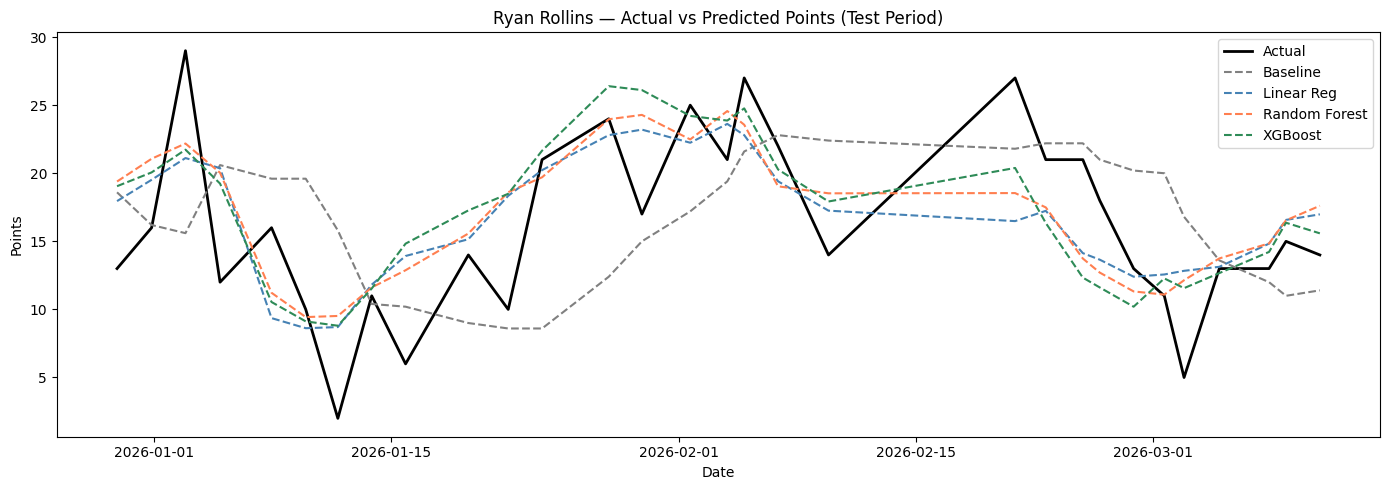

      Date  Actual  Baseline  Linear Reg  Random Forest   XGBoost
2025-12-29    13.0      18.6        18.0           19.4 19.000000
2025-12-31    16.0      16.2        19.5           21.1 20.100000
2026-01-02    29.0      15.6        21.1           22.2 21.700001
2026-01-04    12.0      20.6        20.4           20.0 19.200001
2026-01-07    16.0      19.6         9.4           11.2 10.500000
2026-01-09    10.0      19.6         8.6            9.4  9.100000
2026-01-11     2.0      15.8         8.7            9.5  8.800000
2026-01-13    11.0      10.4        11.8           11.6 11.500000
2026-01-15     6.0      10.2        13.9           12.9 14.800000
2026-01-19    14.0       9.0        15.2           15.6 17.299999
2026-01-21    10.0       8.6        18.3           18.6 18.500000
2026-01-23    21.0       8.6        20.2           19.7 21.700001
2026-01-27    24.0      12.4        22.8           24.0 26.400000
2026-01-29    17.0      15.0        23.2           24.3 26.100000
2026-02-01

In [34]:
# Change this to any player in your dataset
first_name = "Ryan"
last_name  = "Rollins"

matches = df.loc[
    (df["firstName"].str.lower() == first_name.lower()) &
    (df["lastName"].str.lower()  == last_name.lower()), "personId"
]

if len(matches) == 0:
    print(f"No player found matching '{first_name} {last_name}'. Check spelling or try a different player.")
else:
    player_id = matches.iloc[0]

    # Get all their rows from the test set in chronological order
    player_test = test[test["personId"] == player_id].sort_values("gameDateTimeEst")

    # Remove duplicate games caused by index reset in XGBoost cell
    player_test = player_test.drop_duplicates(subset="gameDateTimeEst", keep="first")

    if len(player_test) == 0:
        print(f"{first_name} {last_name} has no games in the test set.")
    else:
        player_X     = player_test[feature_cols_final].astype(float)
        player_y     = player_test[target_col]
        player_dates = player_test["gameDateTimeEst"]

        # Predict with all models
        player_X_scaled = pd.DataFrame(
            scaler.transform(player_X), columns=feature_cols_final
        )

        preds = {
            "Actual":        player_y.values,
            "Baseline":      player_test["roll5_pts_mean"].values,
            "Linear Reg":    lr.predict(player_X_scaled),
            "Random Forest": rf.predict(player_X),
            "XGBoost":       xgb.predict(player_X),
        }

        # Plot actual vs predicted over time
        plt.figure(figsize=(14, 5))
        plt.plot(player_dates, preds["Actual"],        color="black",     linewidth=2,    label="Actual")
        plt.plot(player_dates, preds["Baseline"],      color="gray",      linestyle="--", label="Baseline")
        plt.plot(player_dates, preds["Linear Reg"],    color="steelblue", linestyle="--", label="Linear Reg")
        plt.plot(player_dates, preds["Random Forest"], color="coral",     linestyle="--", label="Random Forest")
        plt.plot(player_dates, preds["XGBoost"],       color="seagreen",  linestyle="--", label="XGBoost")
        plt.title(f"{first_name.title()} {last_name.title()} — Actual vs Predicted Points (Test Period)")
        plt.xlabel("Date")
        plt.ylabel("Points")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Print per-game table
        results_player = pd.DataFrame({
            "Date":          player_dates.dt.date.values,
            "Actual":        preds["Actual"],
            "Baseline":      preds["Baseline"].round(1),
            "Linear Reg":    preds["Linear Reg"].round(1),
            "Random Forest": preds["Random Forest"].round(1),
            "XGBoost":       preds["XGBoost"].round(1),
        })
        print(results_player.to_string(index=False))

        player_archetype = df.loc[df["personId"] == player_id, "archetype_label_saved"].iloc[0]
        print(f"\nPer-model metrics for {first_name.title()} {last_name.title()} ({player_archetype}):")
        print(f"{'Model':<15} {'RMSE':>6} {'MAE':>6} {'R²':>6}")
        print("-" * 36)
        for name, pred in preds.items():
            if name != "Actual":
                rmse = np.sqrt(mean_squared_error(preds["Actual"], pred))
                mae  = mean_absolute_error(preds["Actual"], pred)
                r2   = r2_score(preds["Actual"], pred)
                print(f"{name:<15} {rmse:>6.3f} {mae:>6.3f} {r2:>6.3f}")